Возьмем датасет из 1 лабы (он полностью состоит из нормалищированных числовых признаков)

In [77]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from attr import dataclass

data = pd.read_csv('data.csv')
print(data.info())

target = 'views'

X = data.drop(columns=[target])
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   post_datetime            2000 non-null   float64
 1   views                    2000 non-null   float64
 2   likes                    2000 non-null   float64
 3   comments                 2000 non-null   float64
 4   shares                   2000 non-null   float64
 5   engagement_rate          2000 non-null   float64
 6   sentiment_score          2000 non-null   float64
 7   platform_Instagram       2000 non-null   int64  
 8   platform_TikTok          2000 non-null   int64  
 9   platform_X               2000 non-null   int64  
 10  platform_YouTube Shorts  2000 non-null   int64  
 11  content_type_carousel    2000 non-null   int64  
 12  content_type_image       2000 non-null   int64  
 13  content_type_text        2000 non-null   int64  
 14  content_type_video      

Напишим классы ```Parameter``` и ```Optimizer|Adam```

In [78]:
class He:
    def __init__(self, shape):
        self.shape = shape
  
    def __call__(self):
        std = np.sqrt(2.0 / self.shape[0])
        weights = np.random.randn(*self.shape) * std
        grads = np.zeros(self.shape)
        return weights, grads


class Xavier:
    def __init__(self, shape):
        self.shape = shape
  
    def __call__(self):
        std = np.sqrt(1.0 / self.shape[0])
        weights = np.random.randn(*self.shape) * std
        grads = np.zeros(self.shape)
        return weights, grads


class Parameter:
  def __init__(self, method_init=None, v=0, g=0):
    if method_init is None:
      self.value = v
      self.grad = g
    else:
      self.value, self.grad = method_init()

    self.m = np.zeros_like(self.value)
    self.v = np.zeros_like(self.value)


class Optimizer:
  def __init__(self, parameters, lr=0.01):
    self.parameters = parameters
    self.lr = lr

  def step(self):
    for param in self.parameters:
      param.value -= self.lr * param.grad

  def zero_grad(self):
    for param in self.parameters:
      param.grad = np.zeros_like(param.value)


class OptimizerAdam:
  def __init__(self, parameters, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
    self.parameters = parameters
    self.lr = lr
    self.beta1 = beta1
    self.beta2 = beta2 
    self.eps = eps
    self.t = 0

  def step(self):
    self.t += 1
    for param in self.parameters:
      param.m = self.beta1 * param.m + (1 - self.beta1) * param.grad
      param.v = self.beta2 * param.v + (1 - self.beta2) * (param.grad ** 2)

      m_hat = param.m / (1 - self.beta1 ** self.t)
      v_hat = param.v / (1 - self.beta2 ** self.t)

      param.value -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

  def zero_grad(self):
    for param in self.parameters:
      param.grad = np.zeros_like(param.value)


class Map:
  def __init__(self):
    pass
  
  def get_params(self):
    pass


class opt:
    Adam = OptimizerAdam
    GD = Optimizer


Линейный обучаемый слой

In [79]:
class Linear(Map):
  def __init__(self, din, dout, method_init=He):
    self.W = Parameter(method_init((din, dout)))
    self.b = Parameter(v=np.zeros((dout, )), g=np.zeros((dout, )))

  def get_params(self):
    return [self.W, self.b]

  def forward(self, x):
    self.inp = x
    return x @ self.W.value + self.b.value

  def backward(self, grad):
    self.W.grad = self.inp.T @ grad
    self.b.grad = np.sum(grad, axis=0)

    return grad @ self.W.value.T

In [80]:
class Residual(Map):
  def __init__(self, residual_block):
    super().__init__()
    self.residual_block = residual_block
    self.input_cache = None

  def forward(self, x):
    self.input_cache = x.copy()

    residual_out = x
    for layer in self.residual_block:
      residual_out = layer.forward(residual_out)

    output = x + residual_out
    return output

  def backward(self, grad_output):
    grad_skip = grad_output.copy()
    grad = grad_output

    for layer in reversed(self.residual_block):
      grad = layer.backward(grad)

    return grad + grad_skip

  def get_params(self):
    params = []
    for f in self.residual_block:
      pars = f.get_params()
      if not pars is None: params.extend(pars)

    return params

In [81]:
class RBFLayer(Map):
    def __init__(self, din, dout, gamma=1.0, method_init=Xavier):
        super().__init__()
        self.mu = Parameter(method_init((dout, din))) 
        self.gamma = gamma
        self.inp = None
        self.dist_sq = None
        self.out = None

    def get_params(self):
        return [self.mu]

    def forward(self, x):
        self.inp = x
        x_sq = np.sum(x ** 2, axis=1, keepdims=True)
        mu_sq = np.sum(self.mu.value ** 2, axis=1)
        dist_sq = x_sq - 2 * (x @ self.mu.value.T) + mu_sq

        self.dist_sq = dist_sq
        self.out = np.exp(-self.gamma * dist_sq)
        return self.out

    def backward(self, grad_output):
        y = self.out  # (batch, dout)
        # dy = dL / d(dist_sq)
        dy = grad_output * y * (-self.gamma)  # (batch, dout)

        # Градиент по mu: 2 * (mu * sum(dy) - dy^T @ x)
        sum_dy_cols = np.sum(dy, axis=0, keepdims=True).T # (dout, 1)
        self.mu.grad = 2 * (sum_dy_cols * self.mu.value - dy.T @ self.inp)

        # Градиент по x: 2 * (x * sum(dy) - dy @ mu)
        sum_dy_rows = np.sum(dy, axis=1, keepdims=True) # (batch, 1)
        grad_input = 2 * (sum_dy_rows * self.inp - dy @ self.mu.value)

        return grad_input


In [82]:
class ReLU(Map):
  def __init__(self): super().__init__()

  def forward(self, x):
    self.input_cache = x
    return np.maximum(0, x)

  def backward(self, grad_output):
    grad_input = np.where(self.input_cache > 0, grad_output, 0)
    return grad_input


class Identity(Map):
  def __init__(self): super().__init__()

  def forward(self, x):
    return x

  def backward(self, grad):
    return grad


class Tanh(Map):
  def __init__(self): super().__init__()

  def forward(self, x):
    self.out = np.tanh(x)
    return self.out

  def backward(self, grad):
    grad_input = grad * (1 - self.out ** 2)
    return grad_input

class SoftArgMax(Map):
    def __init__(self): 
        super().__init__()

    def forward(self, x):
        c = np.max(x, axis=-1, keepdims=True)
        exp_x = np.exp(x - c)
        
        self.out = exp_x / np.sum(exp_x, axis=-1, keepdims=True)
        return self.out

    def backward(self, grad_output):
        sum_grad_out = np.sum(grad_output * self.out, axis=-1, keepdims=True)
        grad_input = self.out * (grad_output - sum_grad_out)
        return grad_input


class act:
    ReLU = ReLU
    Identity = Identity
    SoftArgMax = SoftArgMax
    Tanh = Tanh


In [83]:
class MSE(Map):
  def forward(self, y_p, y_t):
    self.y_pred = y_p
    self.y_true = y_t
    return np.mean((y_p - y_t) ** 2)

  def backward(self):
    grad = 2 * (self.y_pred - self.y_true) / len(self.y_pred)
    return grad

class SoftArgMaxCrossEntropy(Map):
    def __init__(self): 
        super().__init__()

    def forward(self, logits, y_true):
        self.y_true = y_true
        
        c = np.max(logits, axis=1, keepdims=True)
        shifted_logits = logits - c
        
        sum_exp = np.sum(np.exp(shifted_logits), axis=1, keepdims=True)
        log_probs = shifted_logits - np.log(sum_exp)
        
        self.probs = np.exp(log_probs)

        loss = -np.sum(y_true * log_probs) / logits.shape[0]
        return loss

    def backward(self):
        grad = (self.probs - self.y_true) / self.probs.shape[0]
        return grad
    
class losses:
    MSE = MSE
    SoftArgMaxCrossEntropy = SoftArgMaxCrossEntropy


In [84]:
class MapComposition:
  def __init__(self, seq=None):
    self.composition = seq

  def forward(self, x_):
    x = x_.copy()
    for f in self.composition:
      x = f.forward(x)

    return x

  def backward(self, grad_):
    grad = grad_.copy()
    for f in reversed(self.composition):
      grad = f.backward(grad)
    
    return grad

  def get_params(self):
    params = []
    for f in self.composition:
      pars = f.get_params()
      if not pars is None: params.extend(pars)

    return params


class nn:
    Modul = MapComposition

    Linear = Linear
    Residual = Residual
    RBFLayer = RBFLayer

    act = act
    losses = losses
    opt = opt


In [85]:
class Net(MapComposition):
  def __init__(self, n, loss=MSE(), optim=OptimizerAdam):
    composition = [
        Linear(n, 10),
        ReLU(),
        Residual([
            Linear(10, 10),
            ReLU()
        ]),
        Linear(10, 1)
    ]
    super().__init__(composition)

    self.loss = loss
    self.opt = optim(super().get_params())

  def fit(self, X, y):
    for i in range(3000):
      y_pred = self.forward(X)
      loss_error = self.loss.forward(y_pred, y)

      if i % 700 == 0:
        print('loss:', loss_error)

      grad = self.loss.backward()
      self.backward(grad)

      self.opt.step()
      self.opt.zero_grad()


  def predict(self, X):
    return self.forward(X)

In [86]:
n = X_train.shape[1]
model = Net(n)

model.fit(np.array(X_train), np.array(y_train).reshape(-1, 1)) # Reshape y_train to be a column vector
y_pred = model.predict(np.array(X_test))

mse = mean_squared_error(y_pred, np.array(y_test).reshape(-1, 1)) # Reshape y_test to be a column vector

print(mse)

loss: 1.2393910662315484
loss: 0.07459525174393196
loss: 0.012649356925275855
loss: 0.0055822297690805945
loss: 0.0033059056872595406
0.004283753972759639


Напишем обертку - констурктуор моделей

In [87]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score

class ExperimentNet(nn.Modul):
    def __init__(self, layers, learning_rate=0.01):
        super().__init__(layers)

        self.loss = nn.losses.SoftArgMaxCrossEntropy()
        self.opt = nn.opt.Adam(self.get_params(), lr=learning_rate)
        self.loss_history = []

    def fit(self, X, y, epochs=500, print_every=100):
        for i in range(epochs):
            logits = self.forward(X)

            loss_val = self.loss.forward(logits, y)
            self.loss_history.append(loss_val)

            if (i + 1) % print_every == 0:
                print(f"Epoch {i + 1}/{epochs} | Loss: {loss_val:.4f}")

            grad = self.loss.backward()
            self.backward(grad)

            self.opt.step()
            self.opt.zero_grad()

    def predict(self, X):
        logits = self.forward(X)
        return np.argmax(logits, axis=1)


def count_parameters(model):
    return sum(p.value.size for p in model.get_params())

Подготовим данные для тестирования

In [88]:
data = load_digits()
X = data.data
y = data.target.reshape(-1, 1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

encoder = OneHotEncoder(sparse_output=False)
y_oh = encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_oh, test_size=0.2, random_state=42)
y_test_labels = np.argmax(y_test, axis=1)

din = X_train.shape[1]
dout = y_oh.shape[1]

In [89]:
dout

10

In [90]:
din

64


Протестируем разные комбинации слоев


In [91]:
configs = []

# "маленькая" модель
model_std_small = ExperimentNet([
    nn.Linear(din, 32),
    nn.act.ReLU(),
    nn.Linear(32, dout)
], learning_rate=0.1)
configs.append(("Std Small", model_std_small))

In [92]:
# "Глубокая" модель
model_std_deep = ExperimentNet([
    nn.Linear(din, 64),
    nn.act.ReLU(),
    nn.Linear(64, 32),
    nn.act.Tanh(),
    nn.Linear(32, dout)
], learning_rate=0.005)
configs.append(("Std Deep", model_std_deep))

In [93]:
# Модель с RBF
model_rbf = ExperimentNet([
    nn.RBFLayer(din, 64, gamma=0.01),
    nn.act.ReLU(),
    nn.Linear(64, dout)
], learning_rate=0.07)
configs.append(("RBF Net", model_rbf))

In [94]:
# Модель с Residual блоком
residual_block = [
    nn.Linear(32, 32),
    nn.act.ReLU(),
    nn.Linear(32, 32)
]

model_hybrid = ExperimentNet([
    nn.RBFLayer(din, 32, gamma=0.02),
    nn.act.ReLU(),
    nn.Residual(residual_block),
    nn.act.ReLU(),
    nn.Linear(32, dout)
], learning_rate=0.001)
configs.append(("Hybrid (RBF+Res)", model_hybrid))

#### 4. Обучение и сбор статистики и визуализация зависимости качества от параметров


Training Std Small...
Epoch 100/400 | Loss: 0.0000
Epoch 200/400 | Loss: 0.0000
Epoch 300/400 | Loss: 0.0000
Epoch 400/400 | Loss: 0.0000

Training Std Deep...
Epoch 100/400 | Loss: 0.0180
Epoch 200/400 | Loss: 0.0050
Epoch 300/400 | Loss: 0.0024
Epoch 400/400 | Loss: 0.0015

Training RBF Net...
Epoch 100/400 | Loss: 0.3488
Epoch 200/400 | Loss: 0.1958
Epoch 300/400 | Loss: 0.1398
Epoch 400/400 | Loss: 0.1072

Training Hybrid (RBF+Res)...
Epoch 100/400 | Loss: 2.1226
Epoch 200/400 | Loss: 1.4608
Epoch 300/400 | Loss: 0.7433
Epoch 400/400 | Loss: 0.4083


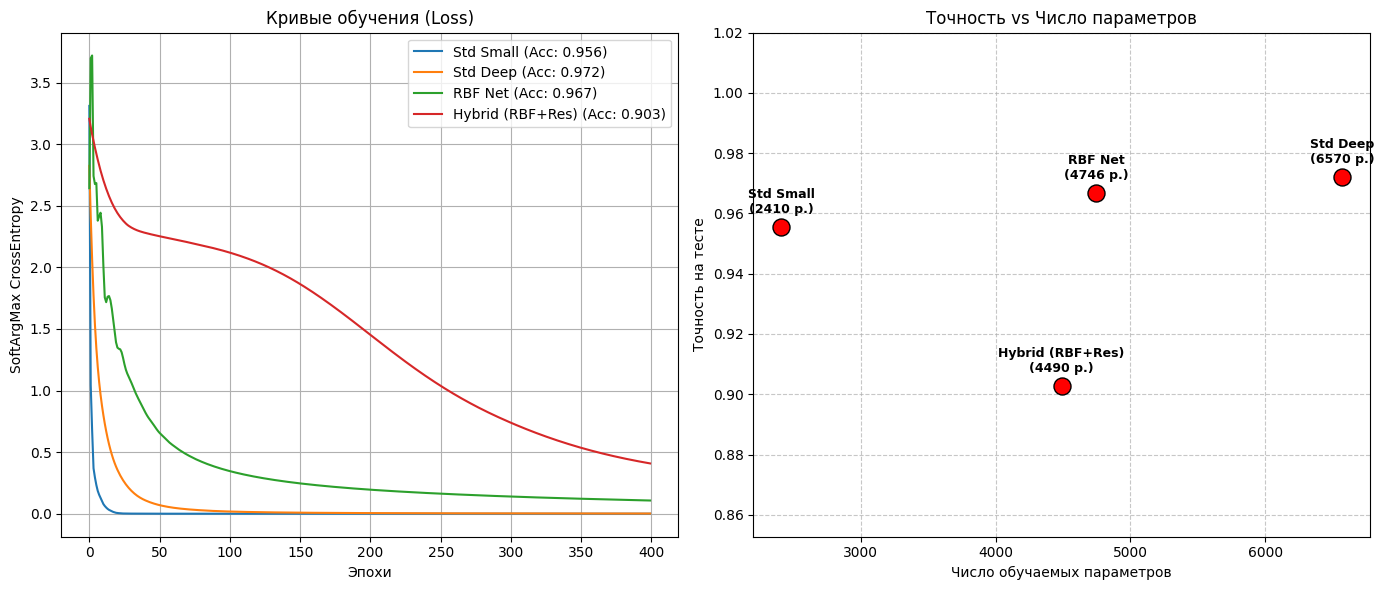


=== Итоговые результаты ===
Модель: Std Small            | Параметров: 2410   | Точность: 0.9556
Модель: Std Deep             | Параметров: 6570   | Точность: 0.9722
Модель: RBF Net              | Параметров: 4746   | Точность: 0.9667
Модель: Hybrid (RBF+Res)     | Параметров: 4490   | Точность: 0.9028


In [95]:
results = []

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)

for name, model in configs:
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train, epochs=400, print_every=100)

    preds = model.predict(X_test)
    acc = accuracy_score(y_test_labels, preds)
    n_params = count_parameters(model)

    results.append({
        'name': name,
        'acc': acc,
        'params': n_params
    })

    plt.plot(model.loss_history, label=f"{name} (Acc: {acc:.3f})")


plt.title("Кривые обучения (Loss)")
plt.xlabel("Эпохи")
plt.ylabel("SoftArgMax CrossEntropy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)

params = [r['params'] for r in results]
accs = [r['acc'] for r in results]
names = [r['name'] for r in results]

plt.scatter(params, accs, s=150, c='red', edgecolors='black', zorder=2)

# Подписи точек
for i, txt in enumerate(names):
    plt.annotate(f"{txt}\n({params[i]} p.)",
                 (params[i], accs[i]),
                 xytext=(0, 10), textcoords='offset points',
                 ha='center', fontsize=9, fontweight='bold')

plt.title("Точность vs Число параметров")
plt.xlabel("Число обучаемых параметров")
plt.ylabel("Точность на тесте")
plt.ylim(min(accs) - 0.05, 1.02)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print()
print("=== Итоговые результаты ===")
for r in results:
    print(f"Модель: {r['name']:<20} | Параметров: {r['params']:<6} | Точность: {r['acc']:.4f}")